In [1]:
import sys
sys.path.append("..")  # Adds the parent directory to the path
from utilities.correlations import *
from utilities.explanation import *
from utilities.for_ploting import *
from utilities.feature_engineering import *
from utilities.imputation import *
from utilities.modelling import *
from utilities.preprocessing import *
from utilities.cleaning import *

pd.set_option('display.max_columns', None)

# Optional: also show full width for each column
pd.set_option('display.expand_frame_repr', False)


Generating 2D Scatter Plot with Color Encoding...


In [2]:
df = pd.read_csv('bank-full.csv', sep=';', encoding="ISO-8859-1")

# EDA

In [3]:
display_basic_info(df)


 Number of Rows and Columns:
 (45211, 17)

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Number of Unique Values:
 age            7

In [4]:
df = df.drop('poutcome',axis=1)

--- Plotting Numerical Features vs Target ('y') ---


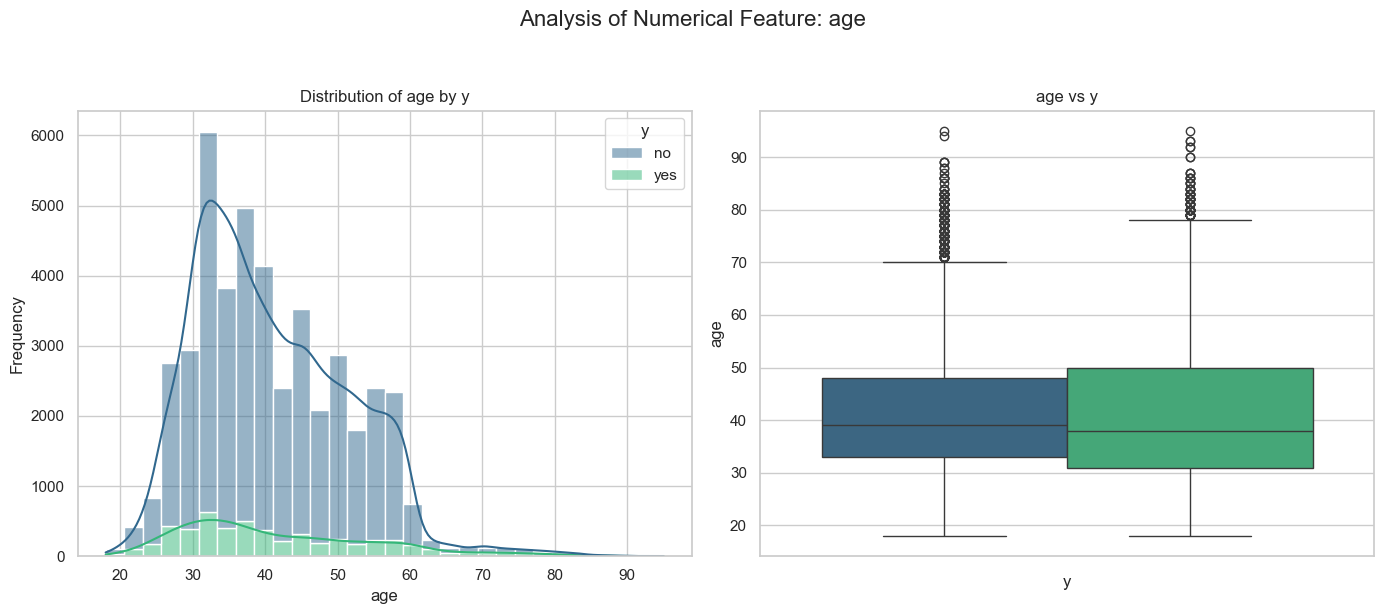

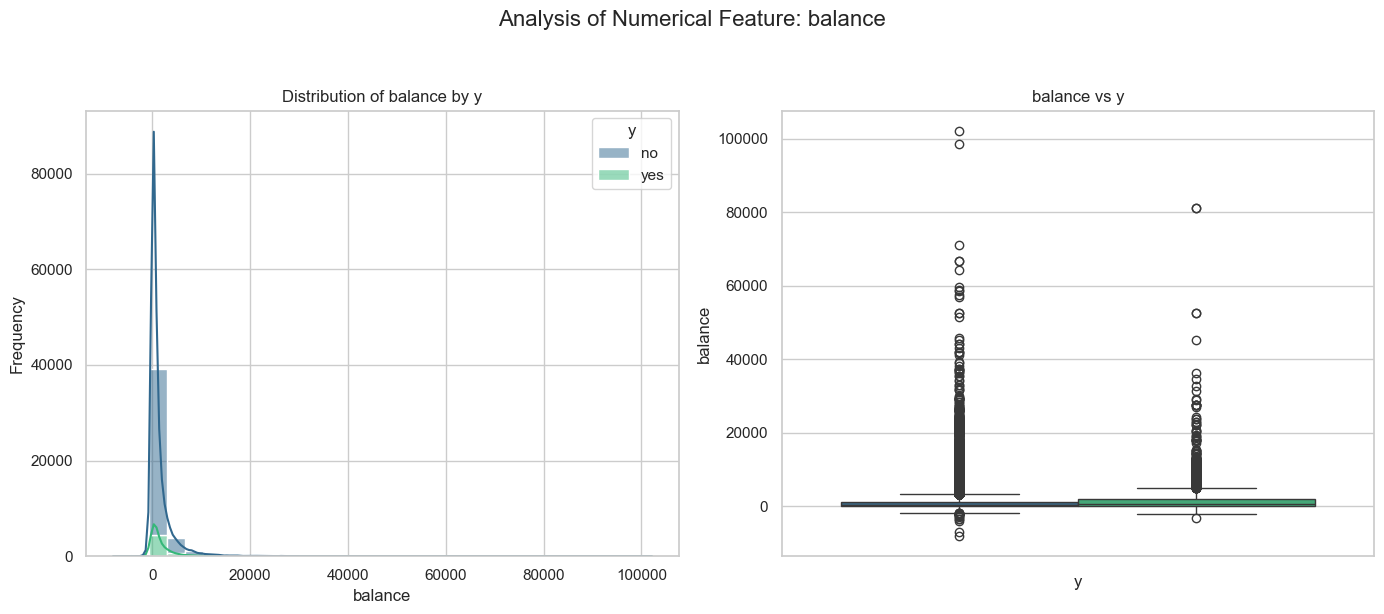

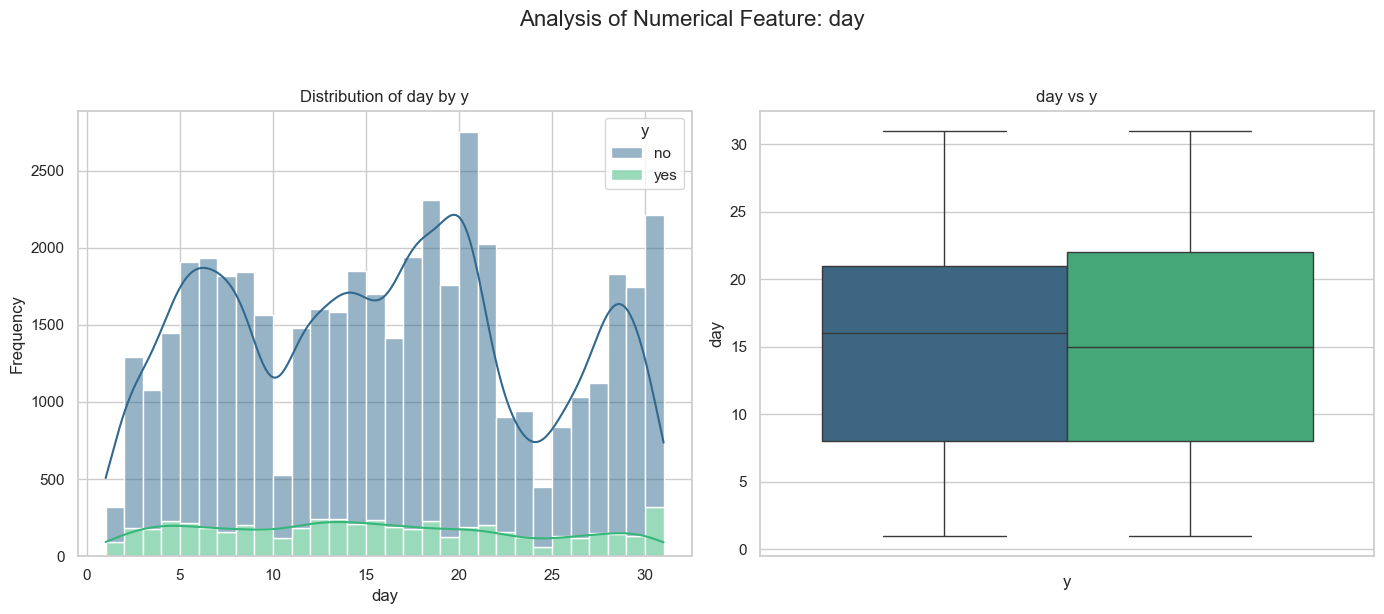

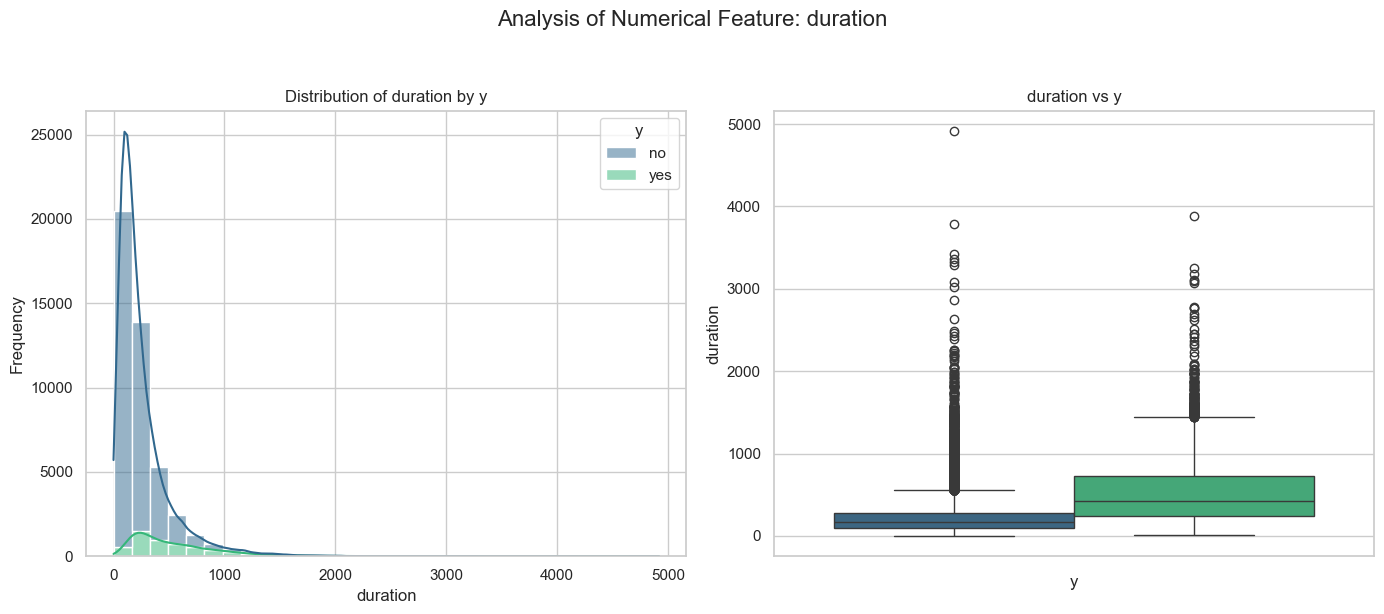

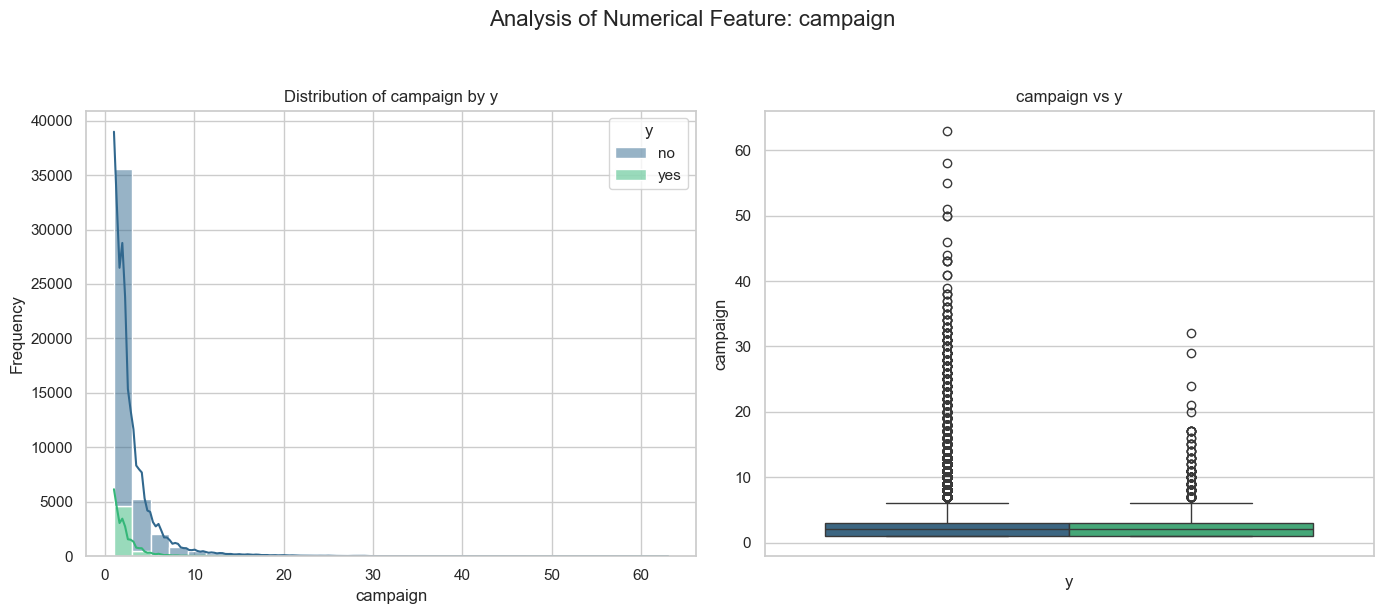

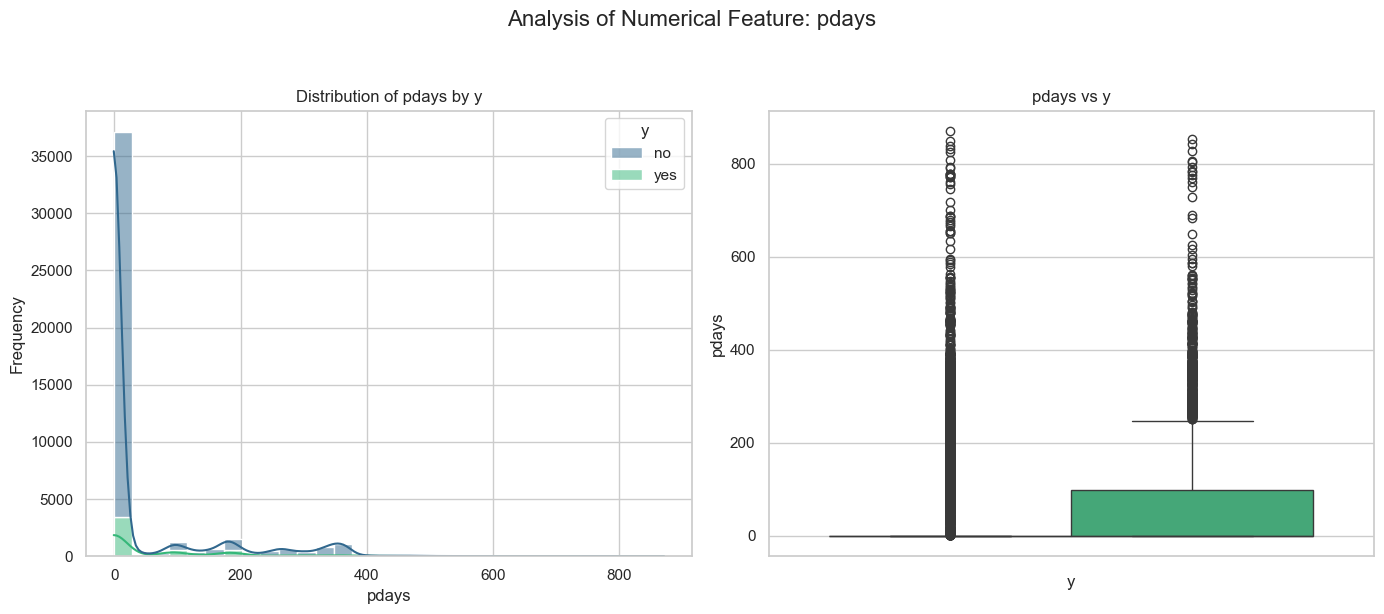

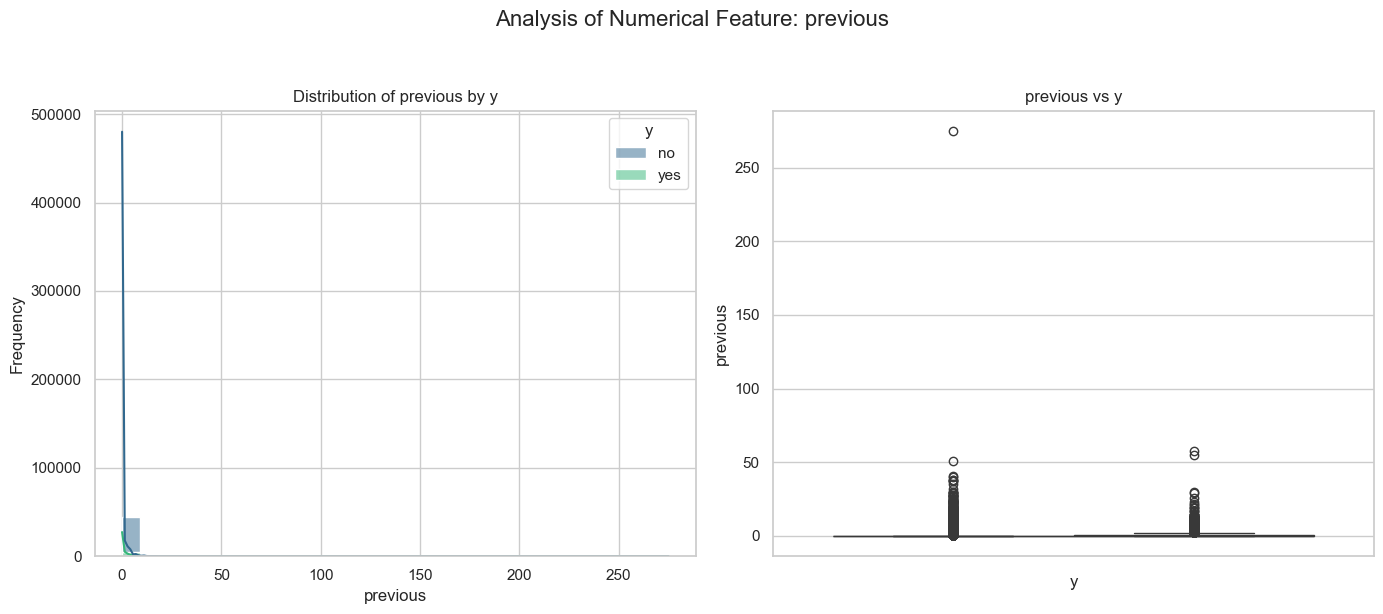

In [5]:
plot_all_num_vs_target(df, 'y')

--- Plotting Categorical Features vs Target ('y') ---


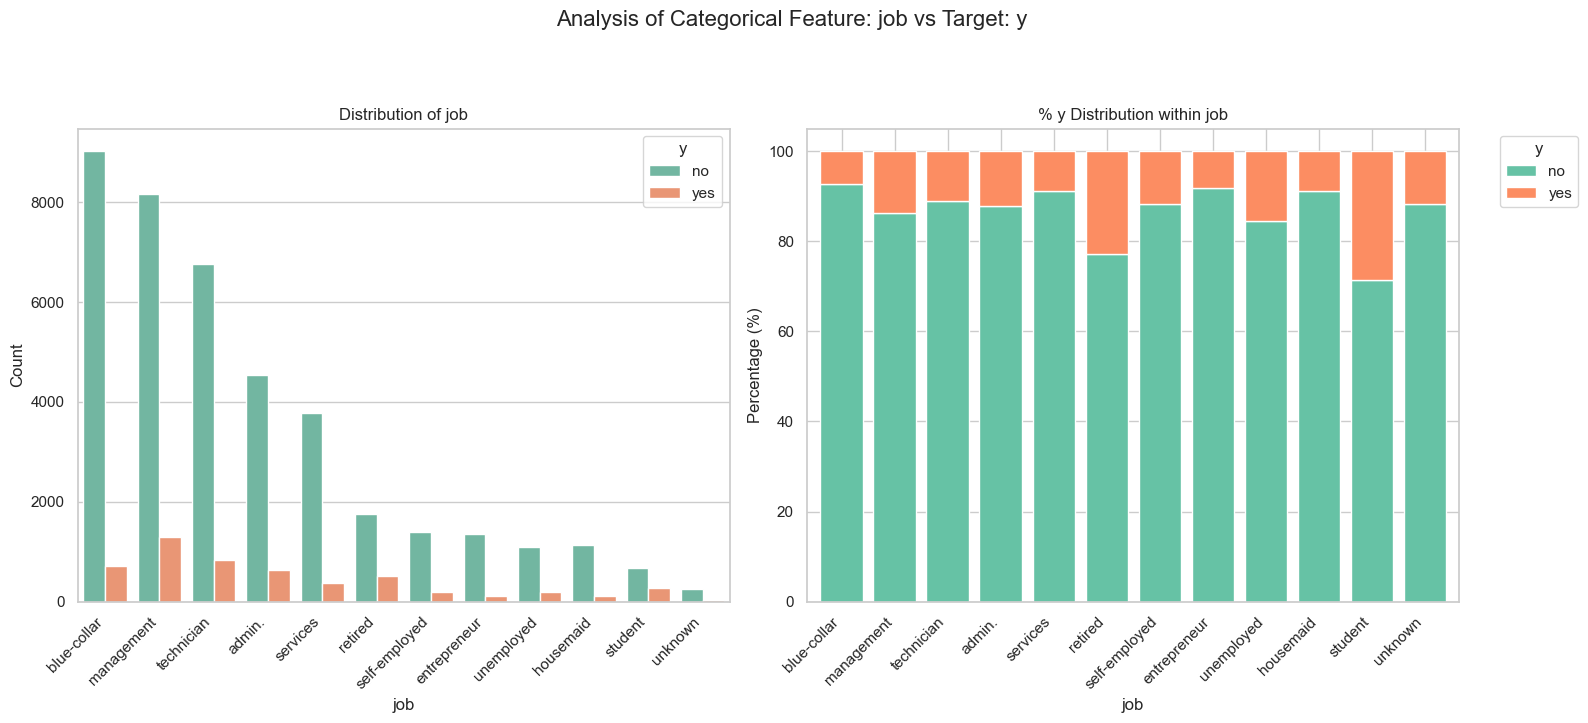

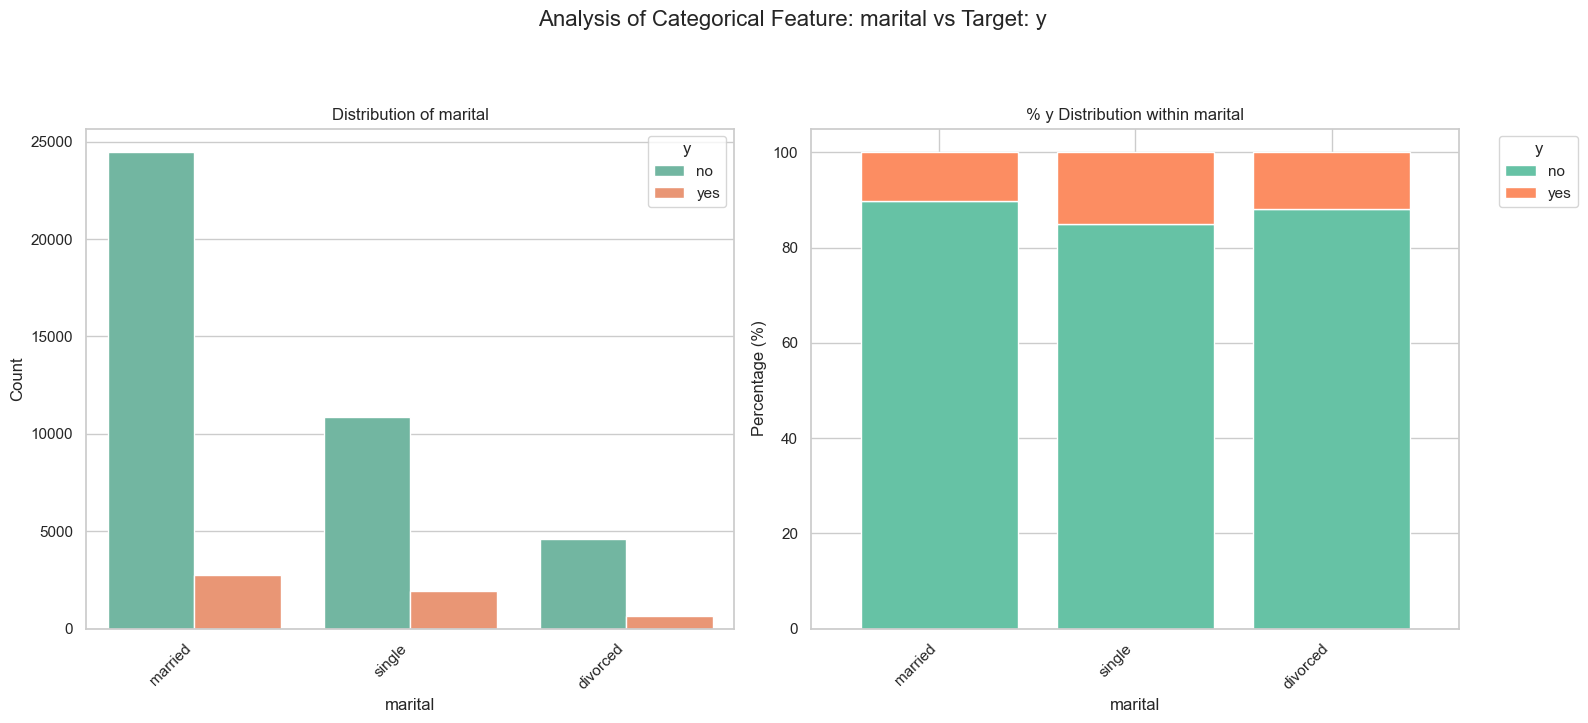

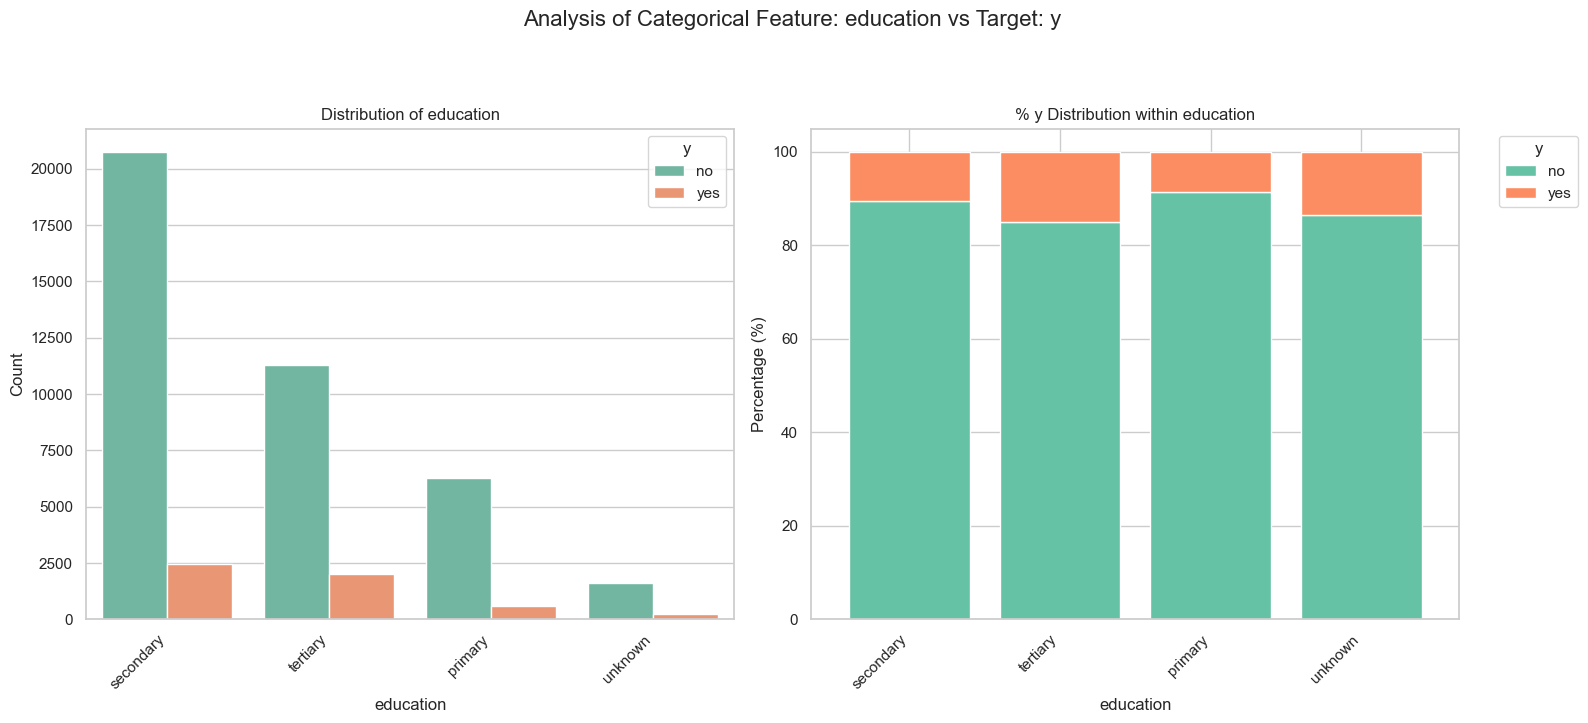

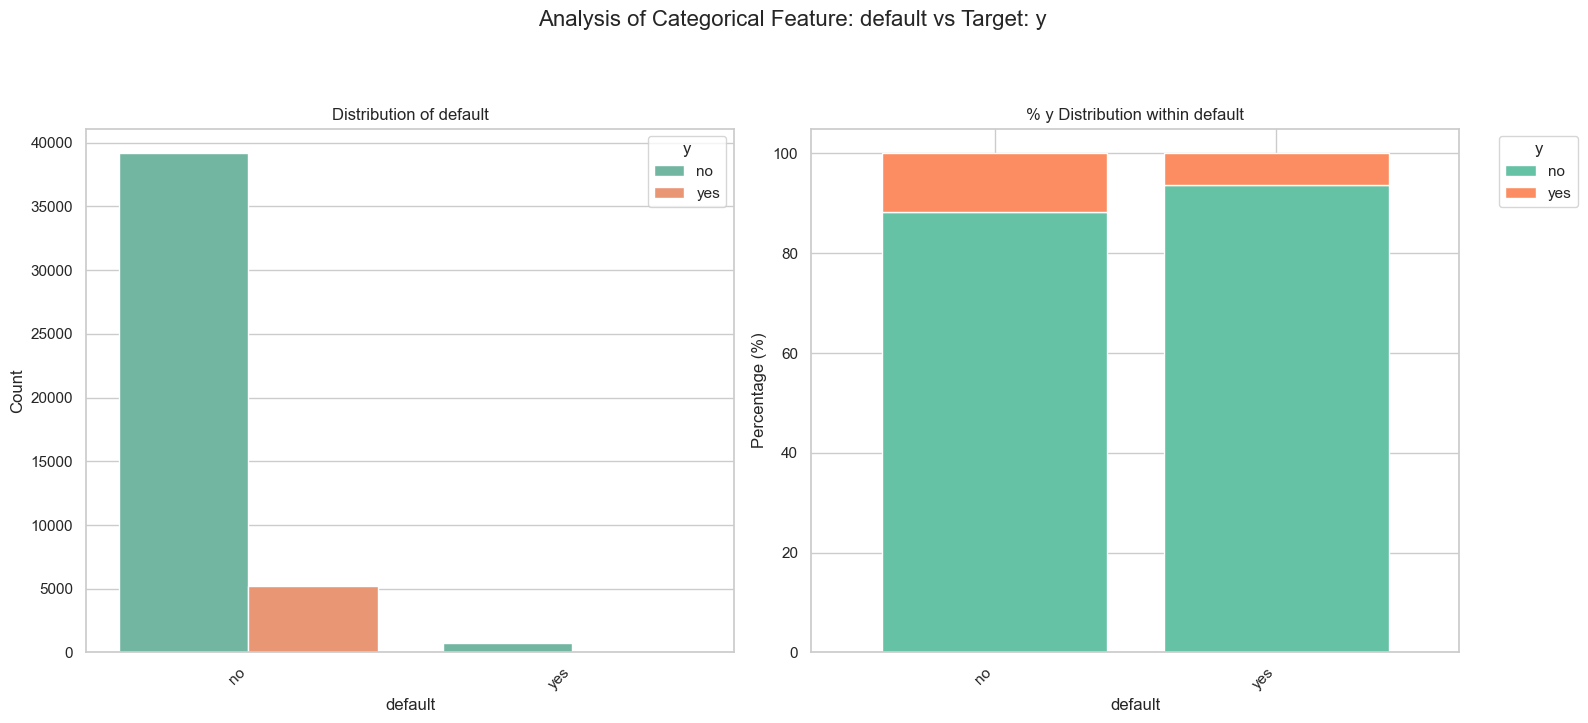

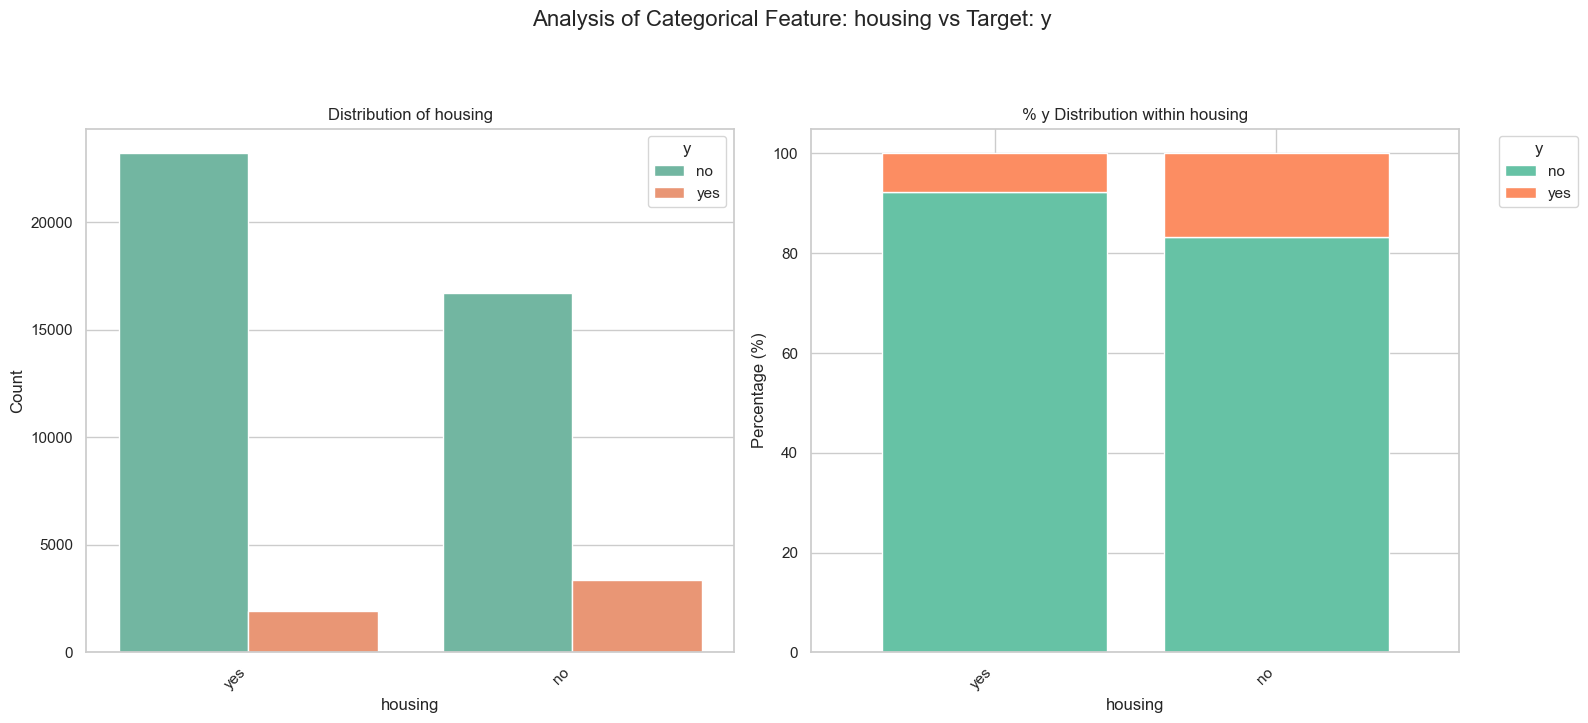

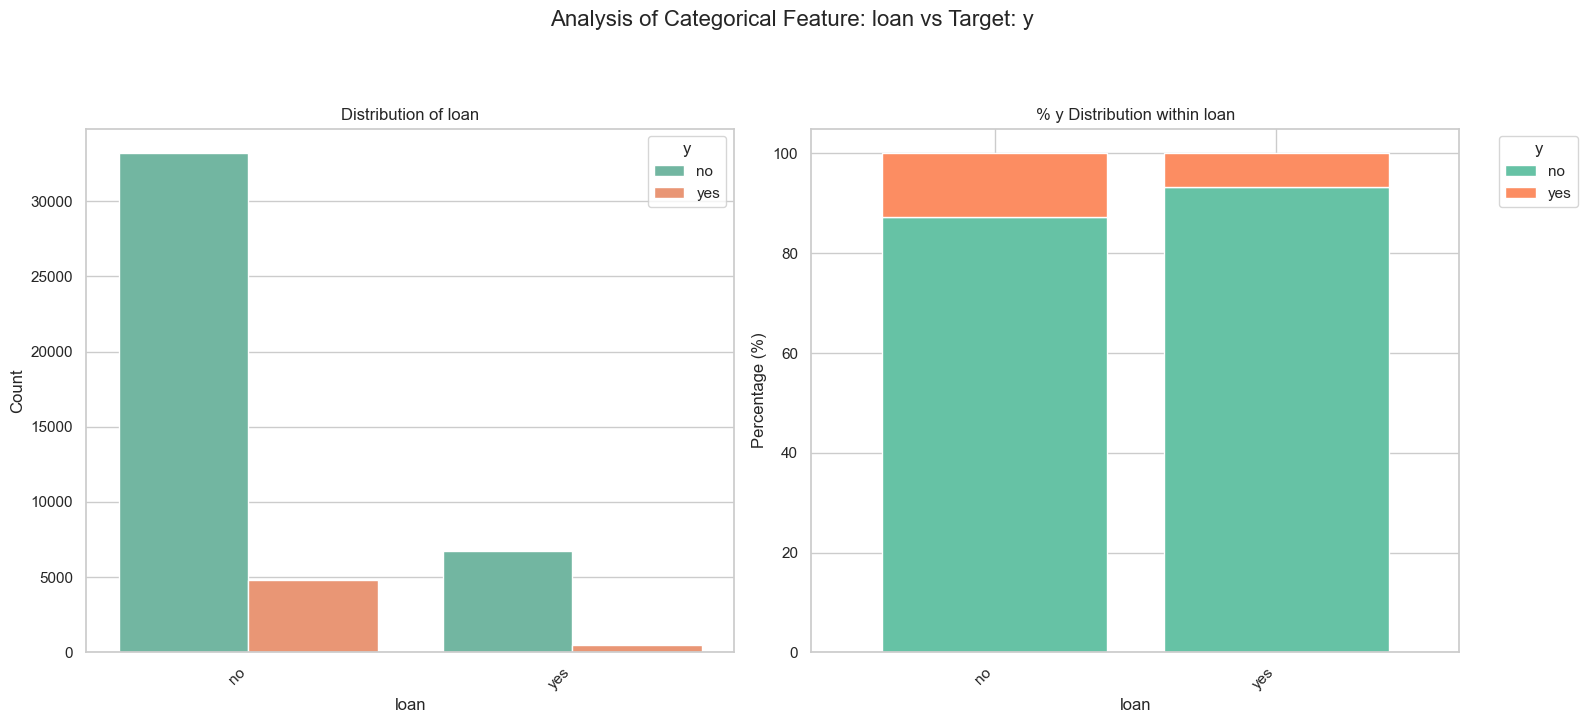

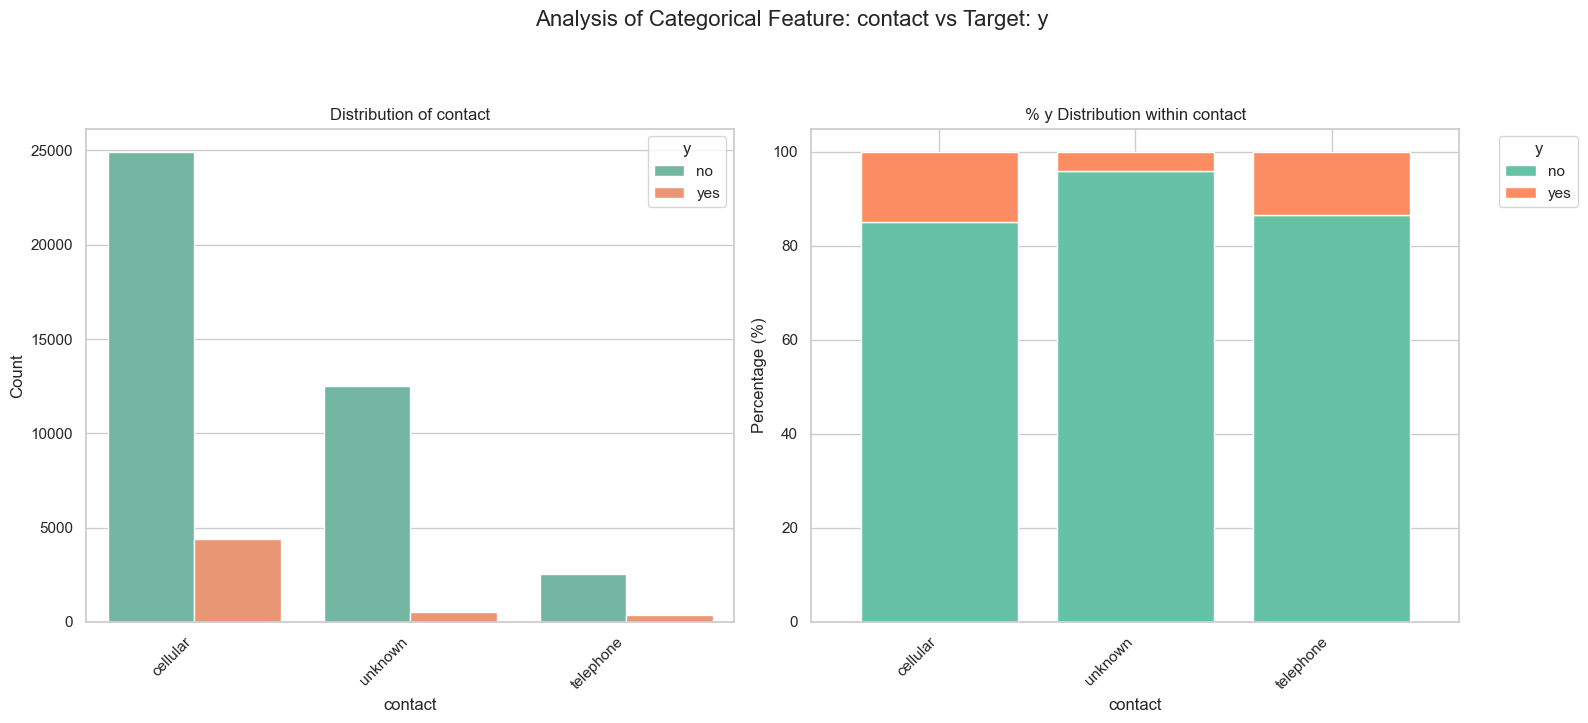

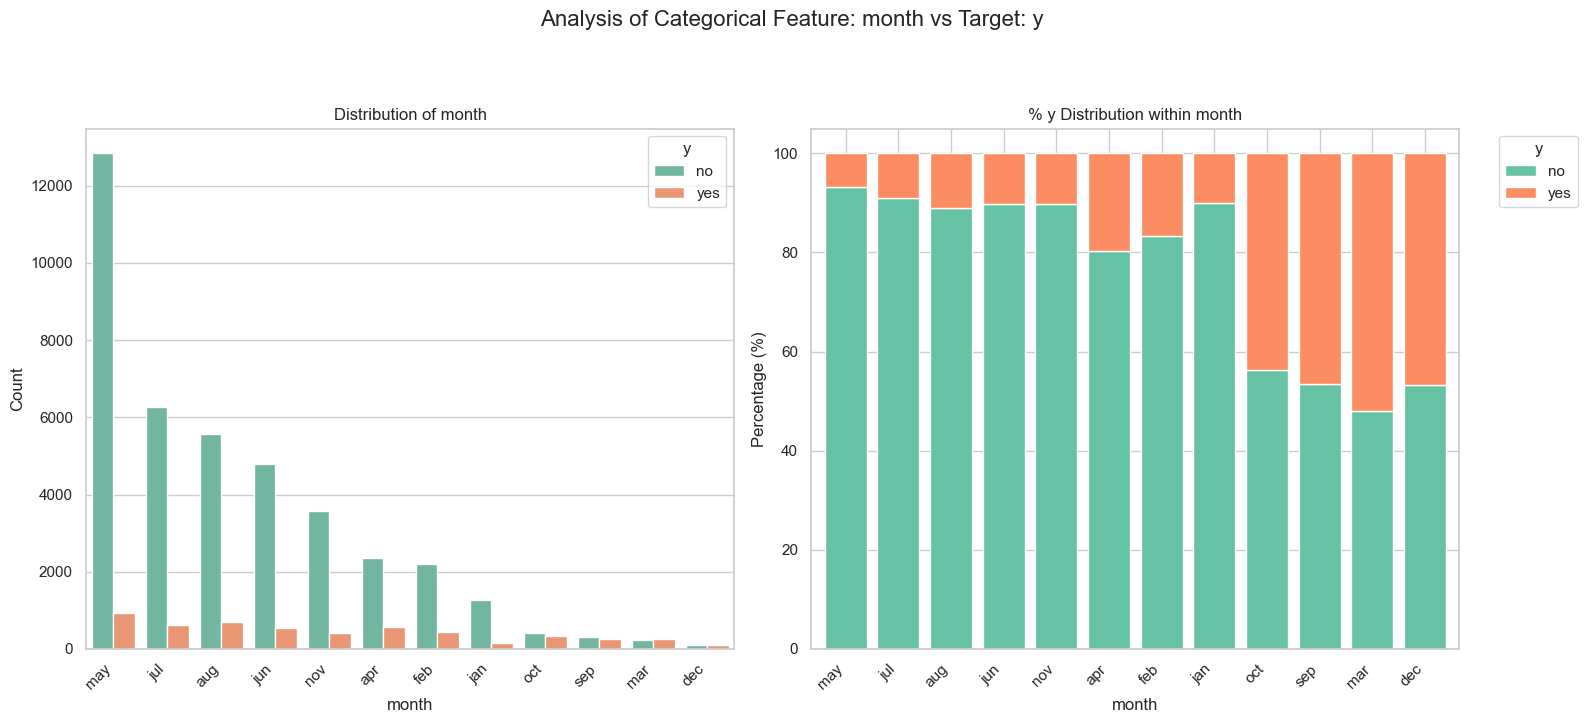

In [6]:
plot_all_cat_vs_target(df, 'y')

In [7]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Training and Evaluation

In [8]:
x = df.drop(columns=['y'],axis=1)
y = df['y'].map({'no':0,'yes':1})

In [9]:
cat_cols = x.select_dtypes(include='object').columns.to_list()
for col in cat_cols:
    x[col] = x[col].astype('category')

In [10]:
from sklearn.model_selection import train_test_split,cross_val_score
from lightgbm import LGBMClassifier

In [11]:
acc, std = cross_val_model_auto(df,'y')
print(f"Accuracy: {100*acc:.2f}% STD: {std:.2f}")

scores: [0.90545173 0.9003539  0.89902676 0.90566246 0.90787436]
Accuracy: 90.37% STD: 0.00


In [12]:
train_x,test_x,train_y,test_y = train_test_split(x,y,test_size=0.2)

Class unbalanced: True
[LightGBM] [Info] Number of positive: 3809, number of negative: 28742
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.820946
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.337972
[LightGBM] [Debug] init for col-wise cost 0.000602 seconds, init for row-wise cost 0.002204 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 987
[LightGBM] [Info] Number of data points in the train set: 32551, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.117016 -> initscore=-2.020993
[LightGBM] [Info] Start training from score -2.020993
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[1]	valid_0's auc: 0.896093	valid_0's binary_logloss:

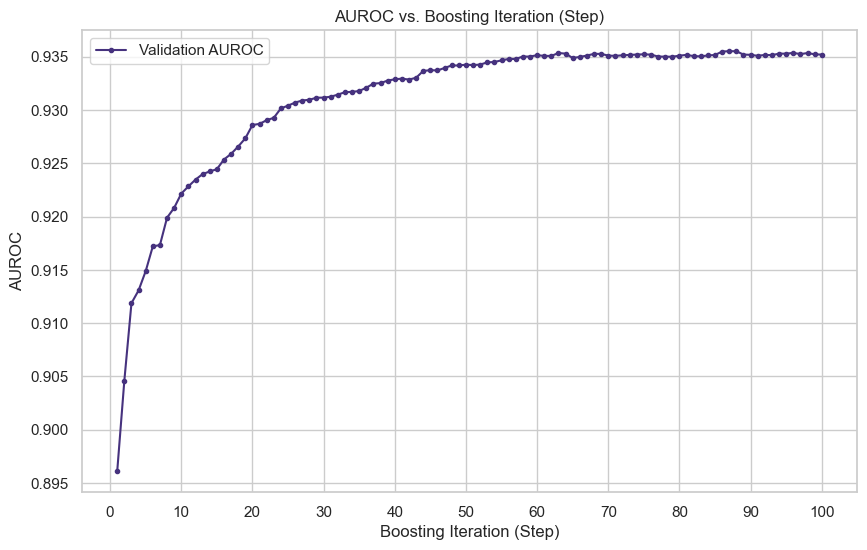


Best Iteration (based on validation AUROC): 87
Best Validation AUROC: 0.9355


In [13]:
model = training_binary_classification_with_lgbm(train_x,train_y,split=0.1)


--- Evaluating LGBMClassifier ---
Accuracy: 0.8534
Precision: 0.4366
Recall: 0.8761
F1 Score: 0.5828
AUC-ROC: 0.9314

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      7986
           1       0.44      0.88      0.58      1057

    accuracy                           0.85      9043
   macro avg       0.71      0.86      0.75      9043
weighted avg       0.92      0.85      0.87      9043



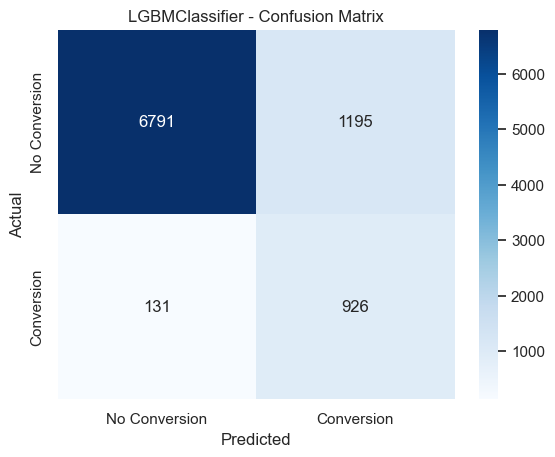

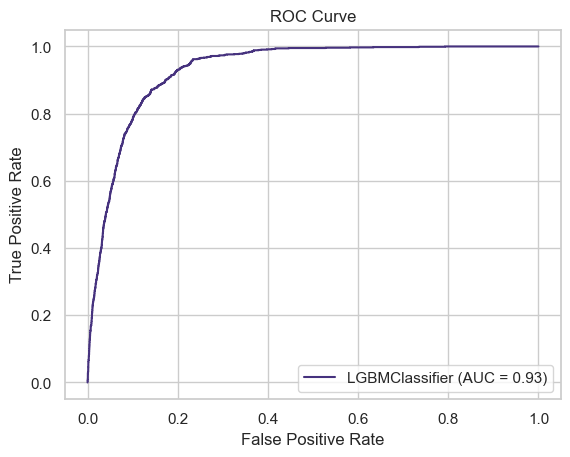

In [14]:
evaluate_binary_classification_model(model, 'LGBMClassifier', test_x, test_y)

# Explanation

C:\Users\qli97\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


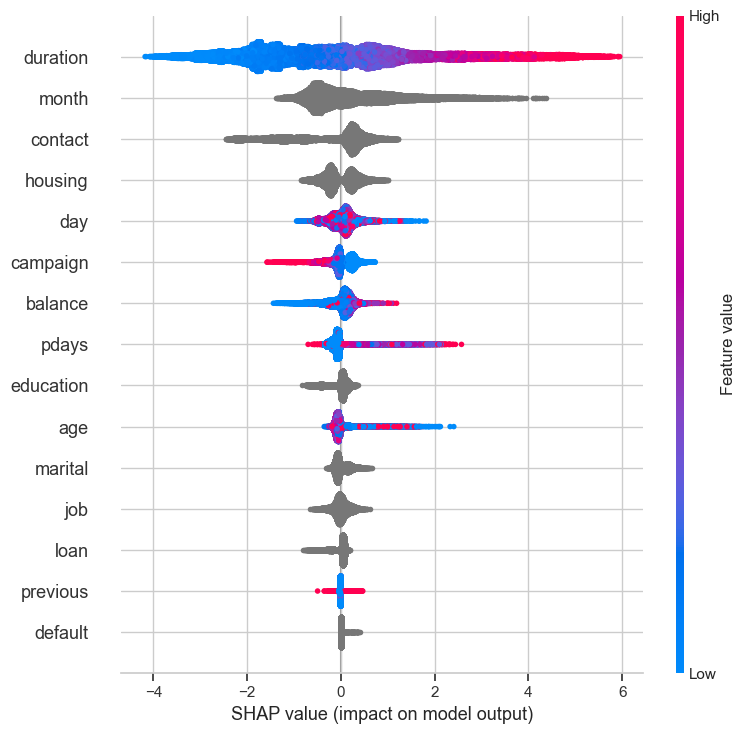

<Figure size 1400x800 with 0 Axes>

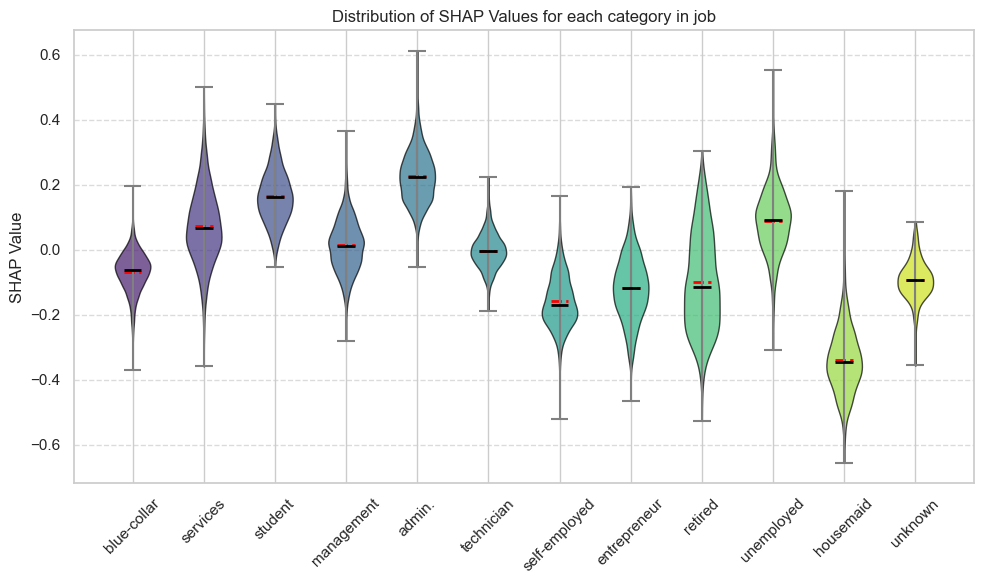

<Figure size 1400x800 with 0 Axes>

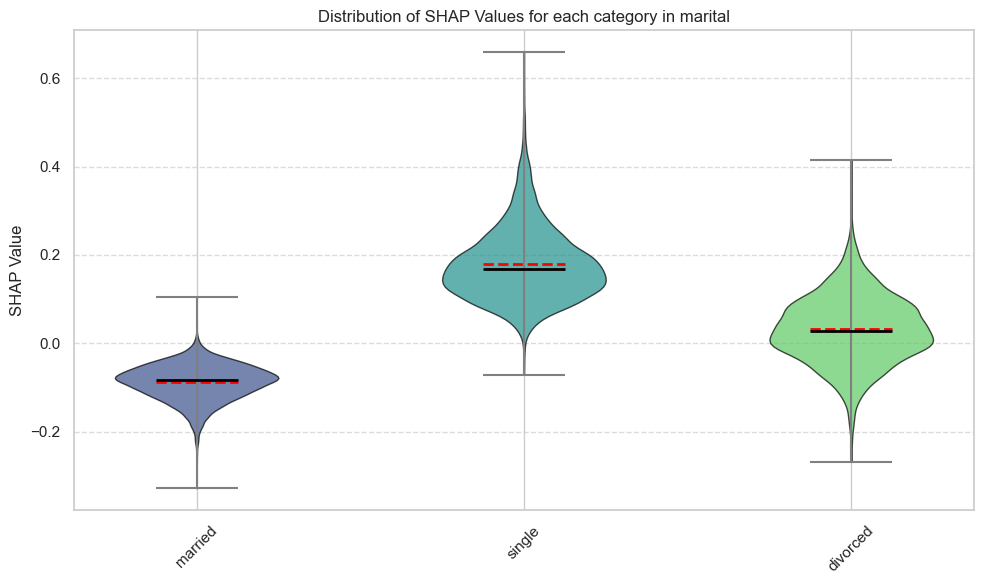

<Figure size 1400x800 with 0 Axes>

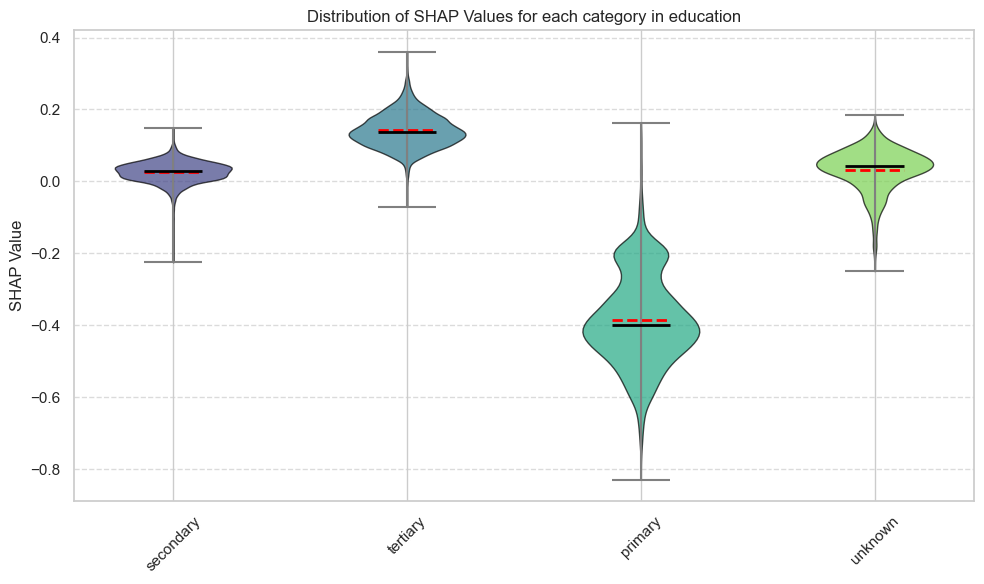

<Figure size 1400x800 with 0 Axes>

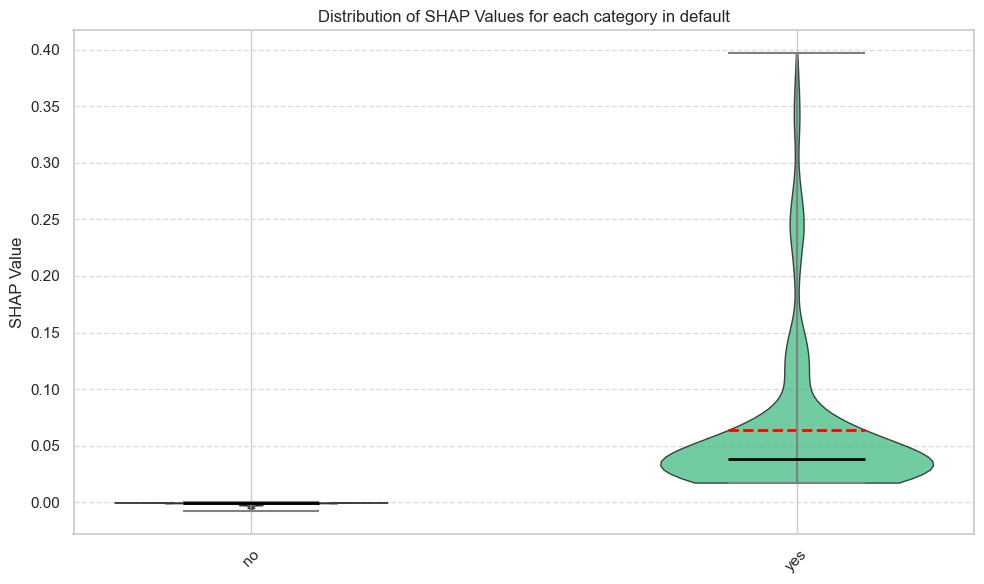

<Figure size 1400x800 with 0 Axes>

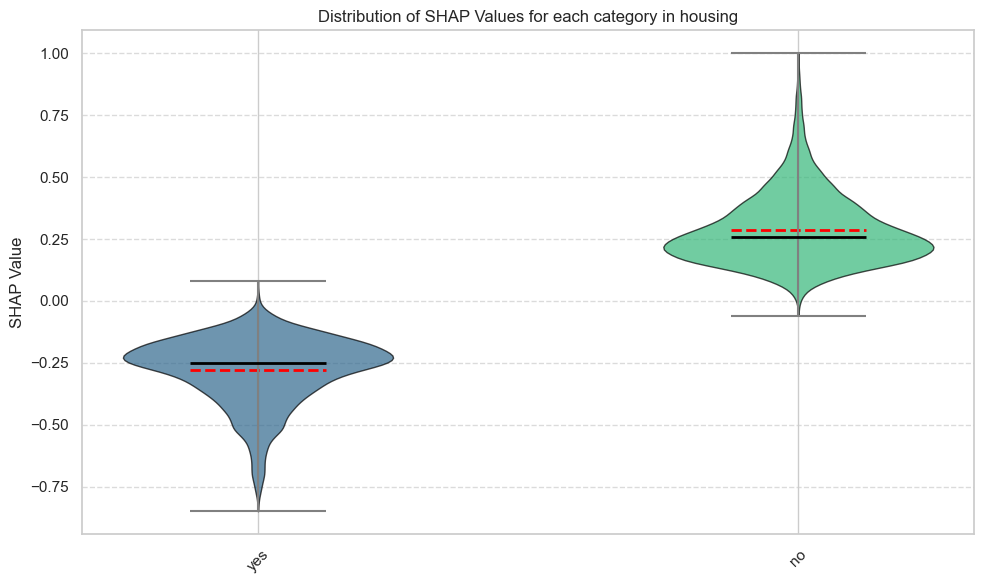

<Figure size 1400x800 with 0 Axes>

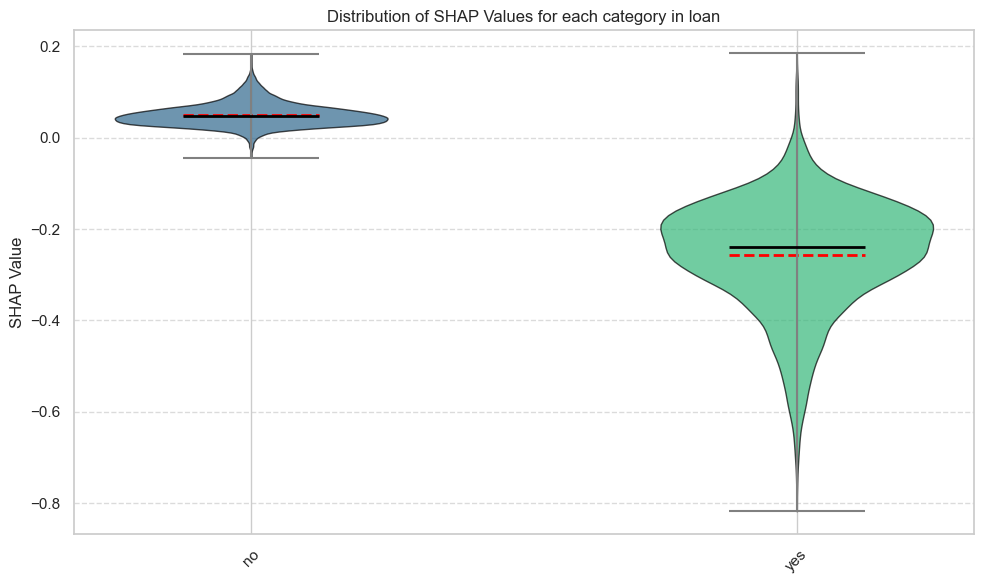

<Figure size 1400x800 with 0 Axes>

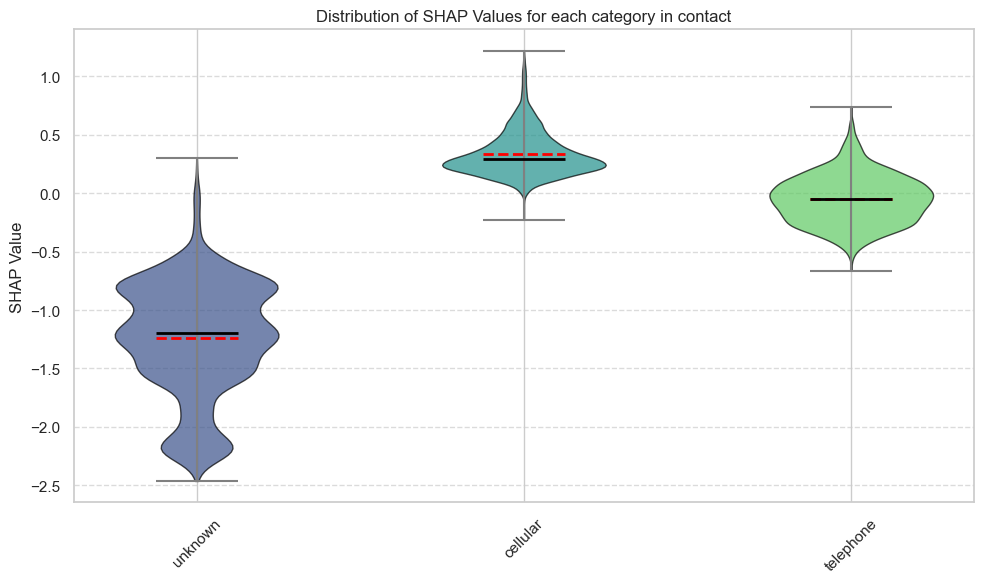

<Figure size 1400x800 with 0 Axes>

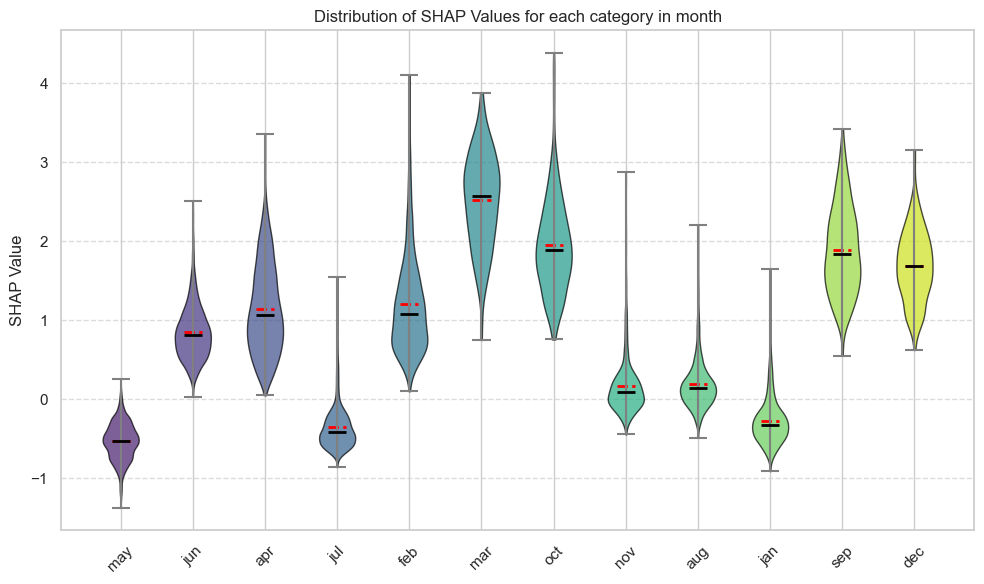

array([[-0.07109369,  0.03589329, -0.08199738, ...,  0.30044846,
        -0.07799687, -0.01329196],
       [-0.06682245, -0.05532092,  0.15898337, ..., -0.02163918,
        -0.10299904, -0.0058744 ],
       [ 0.36584843,  0.12654489,  0.14426305, ...,  0.16730865,
        -0.02367263, -0.03939949],
       ...,
       [-0.04622584, -0.03000592, -0.02201922, ...,  0.2739538 ,
        -0.0630823 , -0.05492691],
       [-0.08008035, -0.28465909, -0.15917414, ...,  0.28234049,
        -0.09444112, -0.0104292 ],
       [-0.08193861, -0.07060536, -0.08878802, ..., -0.24963734,
        -0.13647694, -0.01155416]])

In [20]:
shap_explain_model_on_batch(model, x, x.columns.tolist())

# Dump For App Building

In [15]:
from GeneralPurposeWebApp.generate_config import dump_config_from_df

In [16]:
model_save_path = './LGBMClassifier_model.txt'
model.booster_.save_model(model_save_path)

In [19]:
dump_config_from_df(df, "Term Deposit Subcription Prediction",'y',model_save_path,'config.json')

Configuration template saved to 'config.json'.
Please review and fill in 'model_type', 'model_path', and verify 'class_names' (if applicable).
